In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [225]:
data=pd.read_csv("/content/train_ctrUa4K.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [226]:
data=data.drop(['Loan_ID'],axis=1)

In [227]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [228]:
data['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [229]:
data.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

array([[<Axes: title={'center': 'ApplicantIncome'}>,
        <Axes: title={'center': 'CoapplicantIncome'}>],
       [<Axes: title={'center': 'LoanAmount'}>,
        <Axes: title={'center': 'Loan_Amount_Term'}>],
       [<Axes: title={'center': 'Credit_History'}>, <Axes: >]],
      dtype=object)

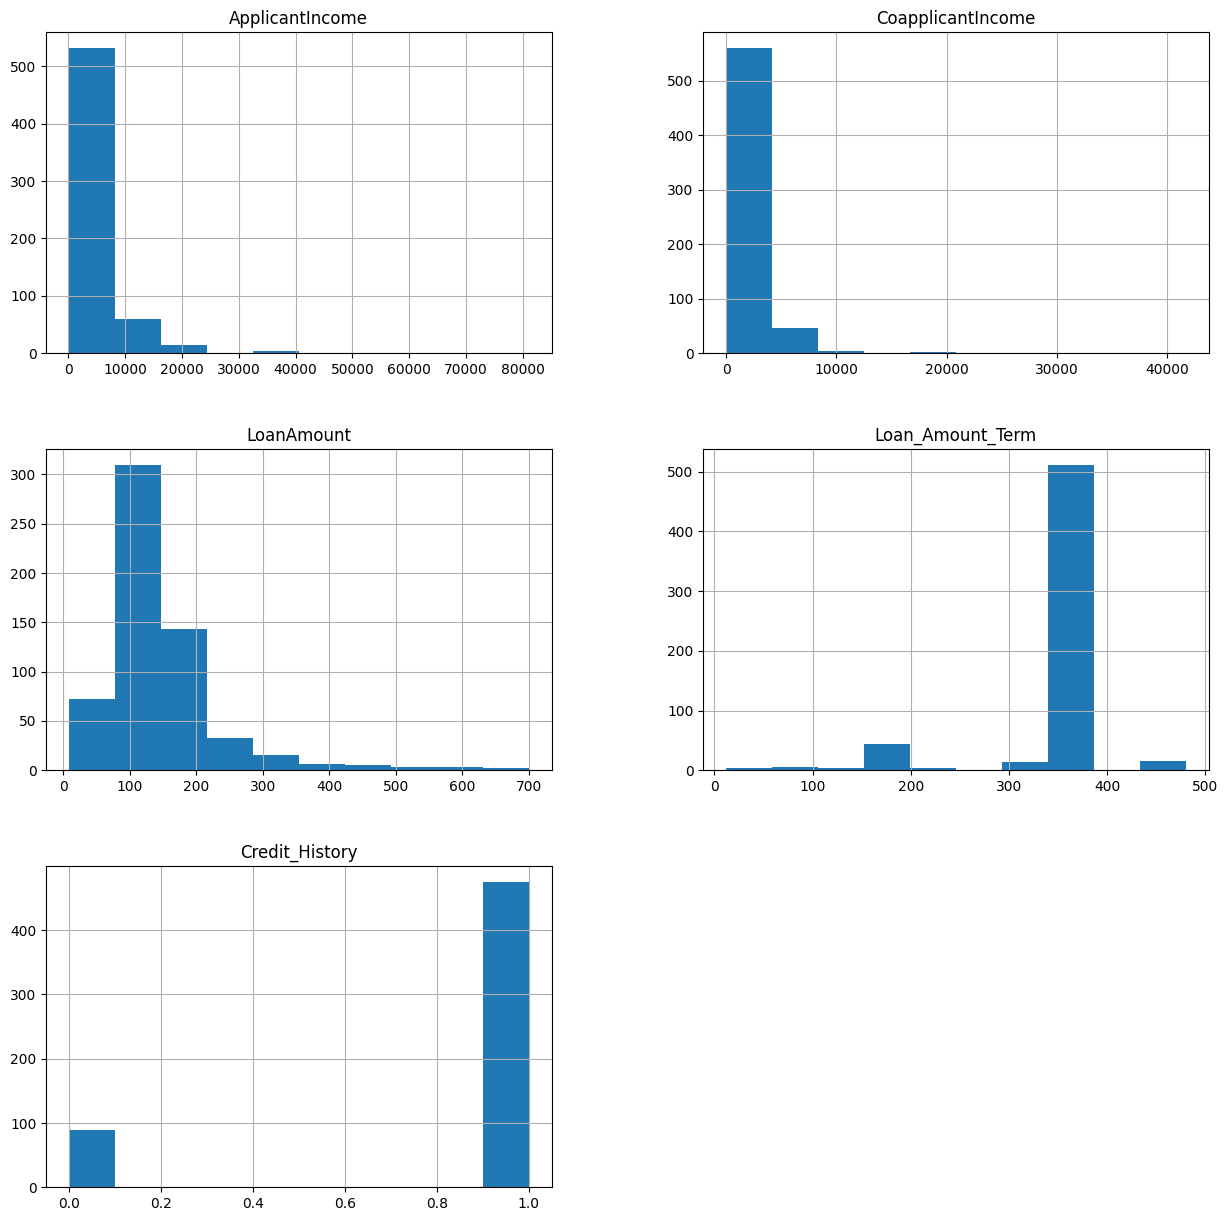

In [230]:
data.hist(figsize=(15,15))

In [231]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [232]:
for i in data.select_dtypes(include=['object']).columns:
  data[i]=data[i].fillna(data[i].mode()[0])

In [233]:
data.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [234]:
data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [235]:
for i in data[['LoanAmount','Loan_Amount_Term', 'Credit_History']]:
       data[i]=data[i].fillna(data[i].median())

In [236]:
data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [237]:
data['Loan_Status']=data['Loan_Status'].map({'Y':1,'N':0})

<Axes: >

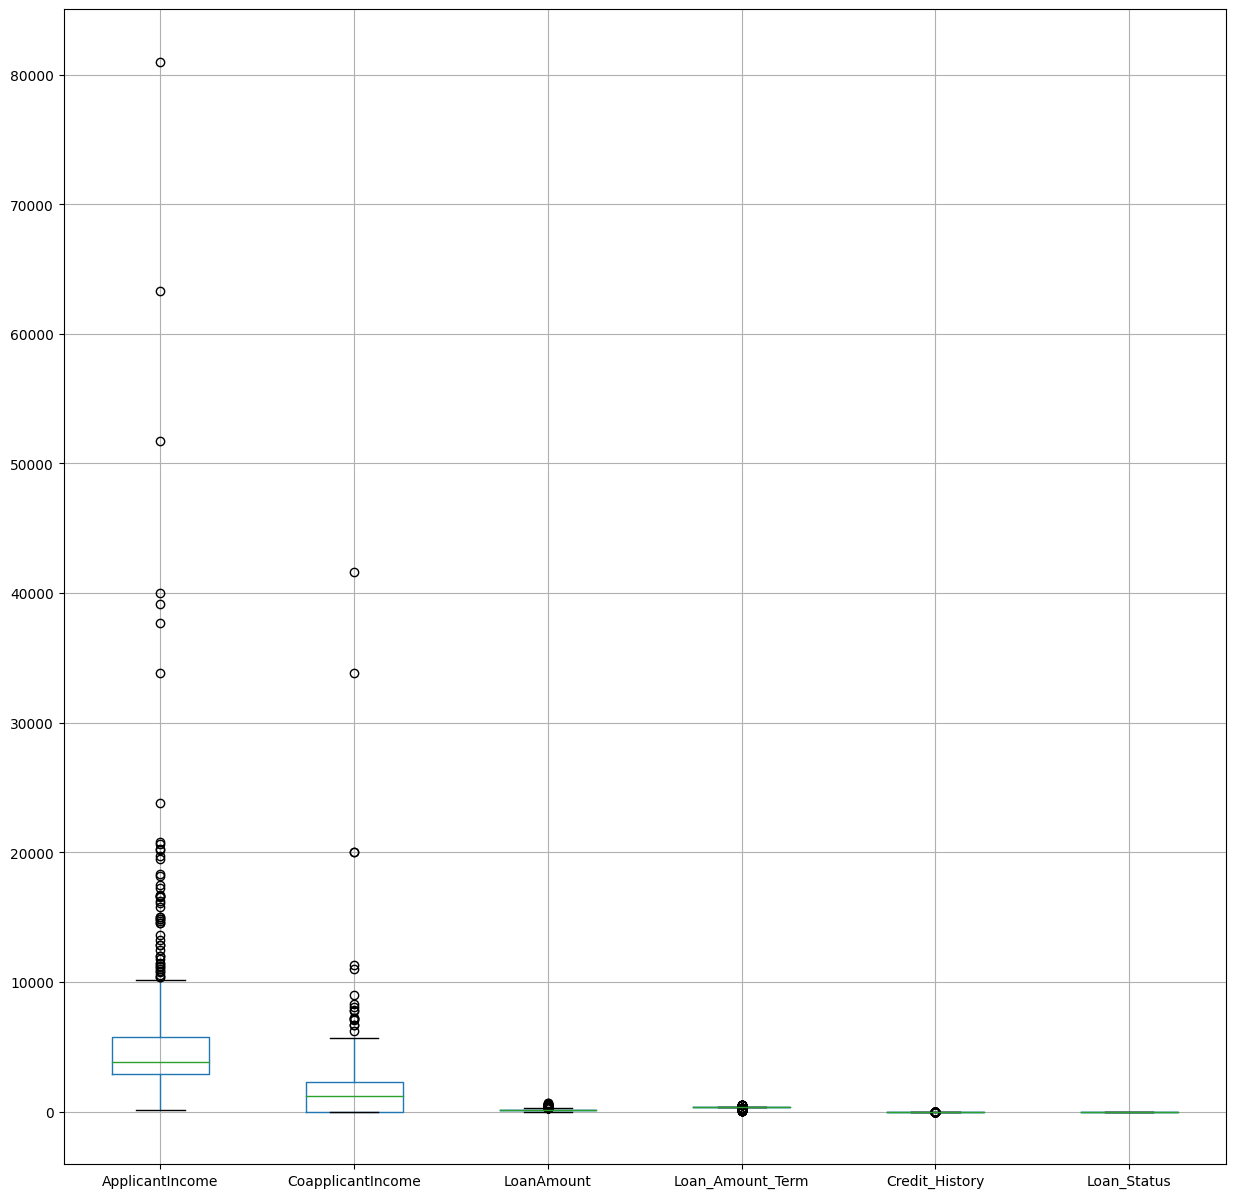

In [238]:
#check for outliers
data.boxplot(figsize=(15,15))

In [239]:
data['Credit_History'].value_counts()

Credit_History
1.0    525
0.0     89
Name: count, dtype: int64

In [240]:
col=['ApplicantIncome','CoapplicantIncome','LoanAmount']
q1=data[col].quantile(0.25)
q3=data[col].quantile(0.75)
iqr=q3-q1
iqr

ApplicantIncome      2917.50
CoapplicantIncome    2297.25
LoanAmount             64.50
dtype: float64

In [241]:
lw_bd=q1-1.5*iqr
up_bd=q3+1.5*iqr
lower=data[col]<lw_bd
upper=data[col]>up_bd
data[col]=data[col].clip(lower=lw_bd,upper=up_bd,axis=1)

<Axes: >

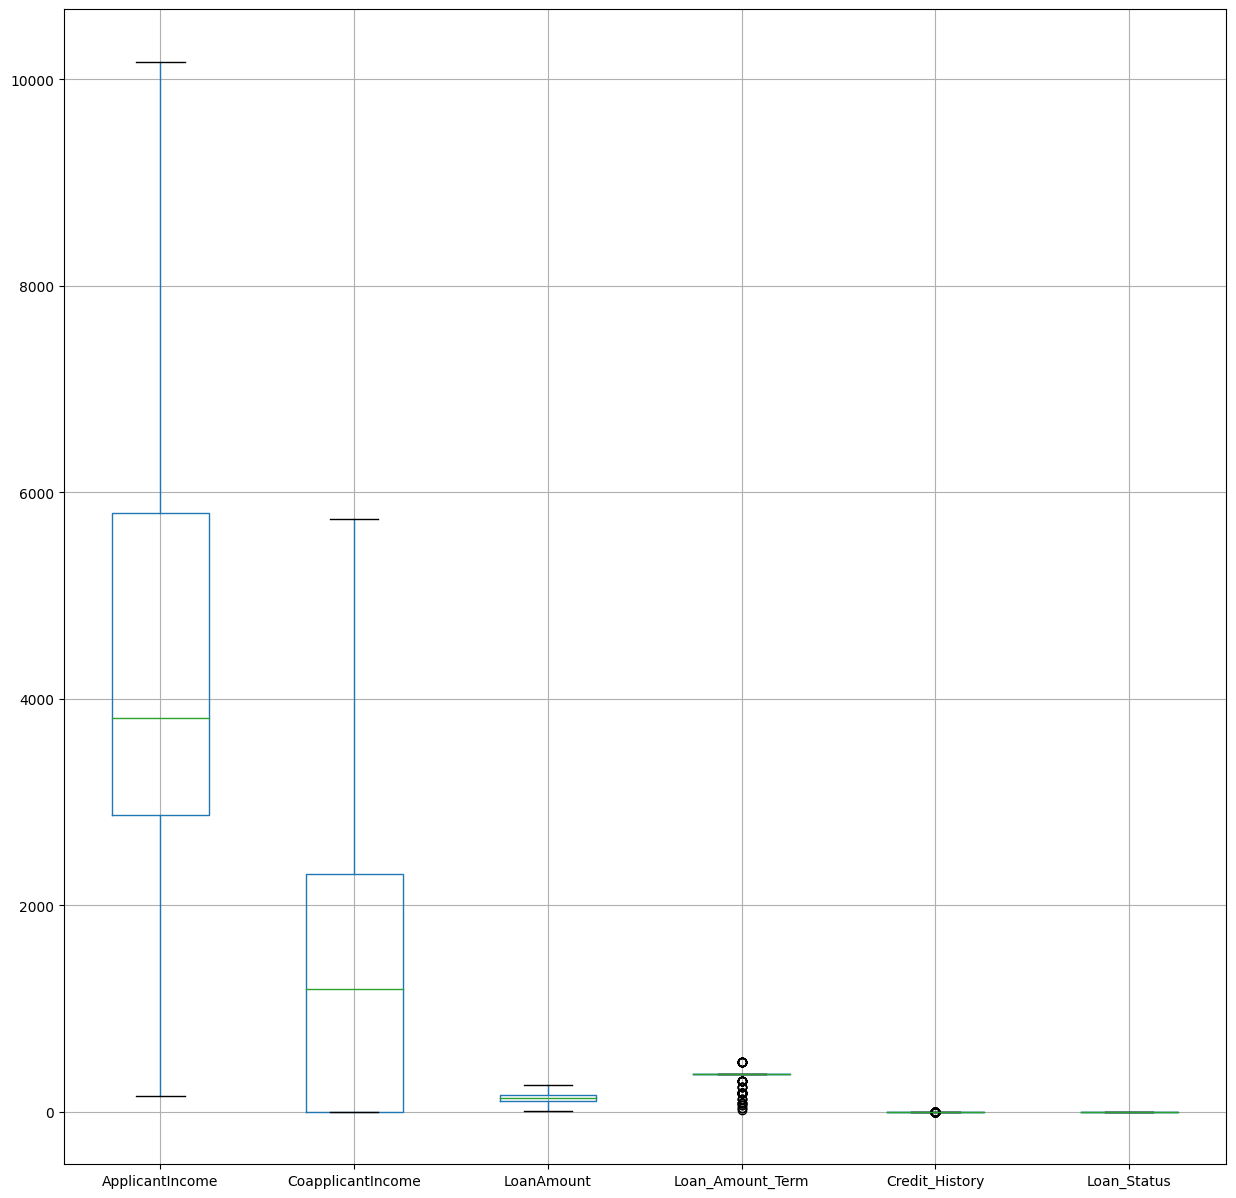

In [242]:
data.boxplot(figsize=(15,15))

In [243]:
data['LoanAmount'].value_counts()

LoanAmount
261.5    41
128.0    33
120.0    20
110.0    17
100.0    15
         ..
228.0     1
236.0     1
156.0     1
65.0      1
253.0     1
Name: count, Length: 168, dtype: int64

In [244]:
data['Credit_History'].value_counts()

Credit_History
1.0    525
0.0     89
Name: count, dtype: int64

In [245]:
data['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    526
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [246]:
num=data.select_dtypes(include=['int64','float64']).columns
num

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status'],
      dtype='object')

In [247]:
data[num].corr()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
ApplicantIncome,1.000000,-0.228956,0.557953,-0.023926,0.035345,-0.000442
CoapplicantIncome,-0.228956,1.000000,0.265021,-0.029295,-0.001710,0.011983
LoanAmount,0.557953,0.265021,1.000000,0.063612,0.004320,-0.047262
Loan_Amount_Term,-0.023926,-0.029295,0.063612,1.000000,-0.004705,-0.022549
Credit_History,0.035345,-0.001710,0.004320,-0.004705,1.000000,0.540556
Loan_Status,-0.000442,0.011983,-0.047262,-0.022549,0.540556,1.000000


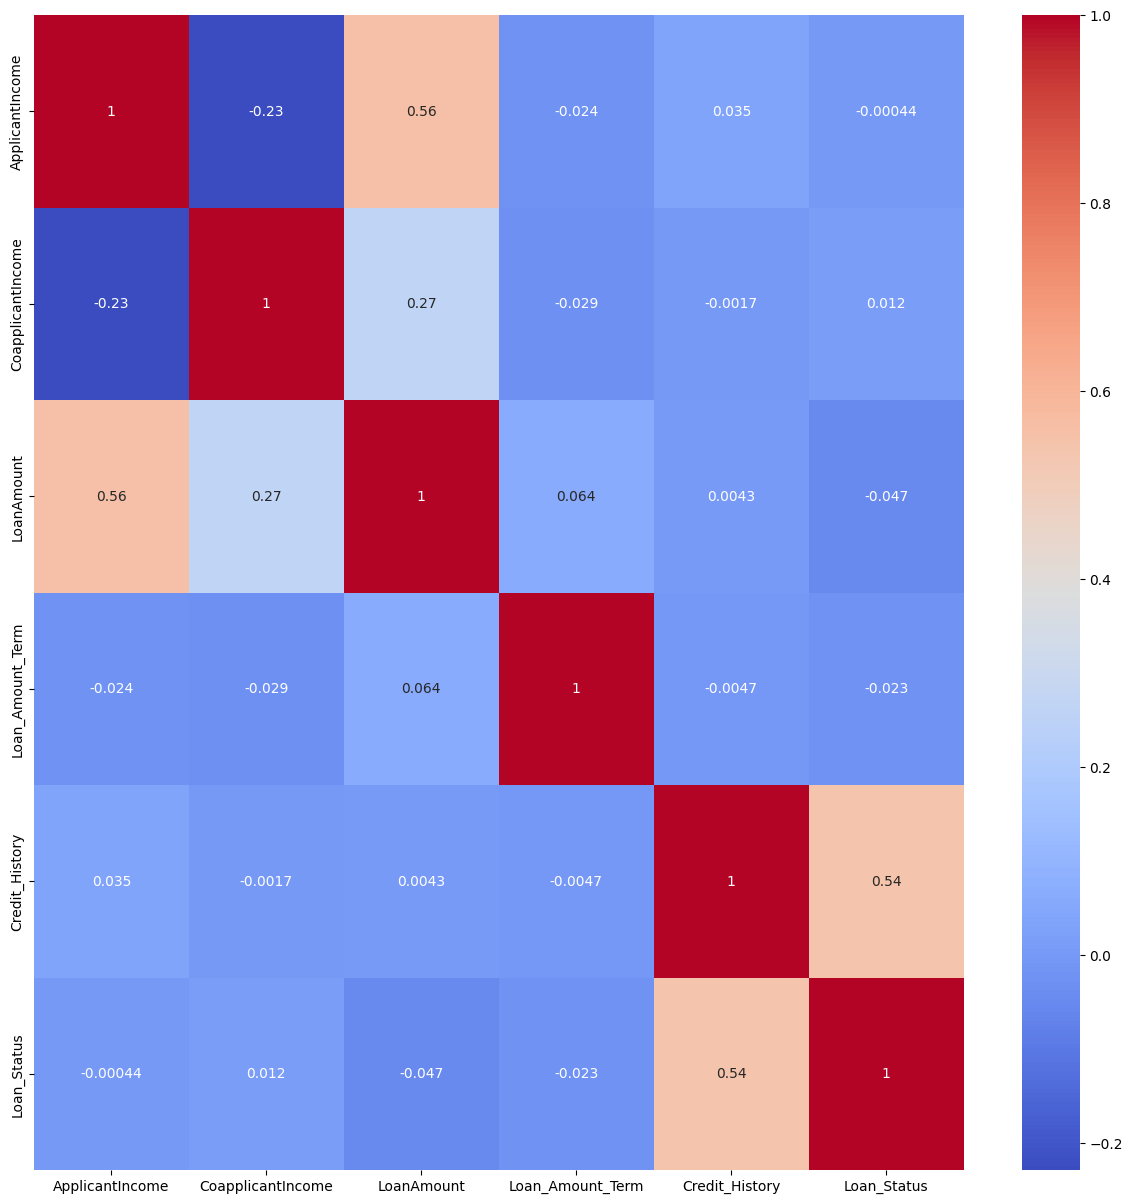

In [248]:
plt.figure(figsize=(15,15))
sns.heatmap(data[num].corr(),annot=True,cmap='coolwarm')
plt.show()

In [249]:
#preprocessing and encoding

In [250]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    float64
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    int64  
dtypes: float64(5), int64(1), object(6)
memory usage: 57.7+ KB


In [251]:
data['Dependents'].value_counts()

Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

In [252]:
data['Gender']=data['Gender'].map({'Male':1,'Female':0})
data['Married']=data['Married'].map({'Yes':1,'No':0})
data['Education']=data['Education'].map({'Graduate':1,'Not Graduate':0})
data['Self_Employed']=data['Self_Employed'].map({'Yes':1,'No':0})


In [253]:
data=pd.get_dummies(data,columns=['Dependents'])
data=pd.get_dummies(data,columns=['Property_Area'])
data.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,1,0,5849.0,0.0,128.0,360.0,1.0,1,True,False,False,False,False,False,True
1,1,1,1,0,4583.0,1508.0,128.0,360.0,1.0,0,False,True,False,False,True,False,False
2,1,1,1,1,3000.0,0.0,66.0,360.0,1.0,1,True,False,False,False,False,False,True
3,1,1,0,0,2583.0,2358.0,120.0,360.0,1.0,1,True,False,False,False,False,False,True
4,1,0,1,0,6000.0,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,True


In [254]:
#scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
data['ApplicantIncome']=sc.fit_transform(data[['ApplicantIncome']])
data['CoapplicantIncome']=sc.fit_transform(data[['CoapplicantIncome']])
data['LoanAmount']=sc.fit_transform(data[['LoanAmount']])
data['Loan_Amount_Term']=sc.fit_transform(data[['Loan_Amount_Term']])

In [255]:
data.describe()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,614.000000,614.000000
mean,0.817590,0.653094,0.781759,0.133550,1.764784e-16,9.257886e-17,1.012581e-16,5.930833e-17,0.855049,0.687296
std,0.386497,0.476373,0.413389,0.340446,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,0.352339,0.463973
min,0.000000,0.000000,0.000000,0.000000,-1.802831e+00,-8.745873e-01,-2.303171e+00,-5.132498e+00,0.000000,0.000000
25%,1.000000,0.000000,1.000000,0.000000,-7.020702e-01,-8.745873e-01,-6.659388e-01,2.732313e-01,1.000000,0.000000
50%,1.000000,1.000000,1.000000,0.000000,-3.247241e-01,-1.424288e-01,-1.680408e-01,2.732313e-01,1.000000,1.000000
75%,1.000000,1.000000,1.000000,0.000000,4.753707e-01,5.406008e-01,4.913377e-01,2.732313e-01,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,2.241532e+00,2.663383e+00,2.227252e+00,2.137276e+00,1.000000,1.000000


In [256]:
#spliting into x and y
x=data.drop(['Loan_Status'],axis=1)
y=data['Loan_Status']

In [257]:
#spliting to train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=68)

In [258]:
#training
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [259]:
ypred=dt.predict(x_test)

In [260]:
#check the performance of model
from sklearn.metrics import accuracy_score,confusion_matrix
print(accuracy_score(y_test,ypred).round(3))
print(confusion_matrix(y_test,ypred))

0.707
[[21 14]
 [22 66]]


In [261]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(penalty='l2',random_state=68)
lr.fit(x_train,y_train)

LogisticRegression(random_state=68)

In [262]:
ypred=lr.predict(x_test)

In [263]:
from sklearn.metrics import accuracy_score,confusion_matrix
print(accuracy_score(y_test,ypred))
print(confusion_matrix(y_test,ypred))

0.7967479674796748
[[13 22]
 [ 3 85]]


In [264]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(criterion='entropy',max_features='log2',n_estimators=2500,max_depth=10,random_state=68)
rf.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', max_depth=10, max_features='log2',
                       n_estimators=2500, random_state=68)

In [265]:
ypred=rf.predict(x_test)

In [266]:
from sklearn.metrics import accuracy_score,confusion_matrix
print(accuracy_score(y_test,ypred).round(3))
print(confusion_matrix(y_test,ypred))

0.805
[[14 21]
 [ 3 85]]


In [267]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [268]:
y_pred=knn.predict(x_test)

In [269]:
print(accuracy_score(y_test, y_pred))

0.7235772357723578


In [270]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_train,y_train)

SVC()

In [271]:
y_pred=svm.predict(x_test)

In [272]:
accuracy_score(y_test,y_pred)

0.8130081300813008

In [273]:
confusion_matrix(y_test,y_pred)

array([[14, 21],
       [ 2, 86]])

Since SVM achieved the highest accuracy of 81%


In [274]:
test=pd.read_csv('/content/test_lAUu6dG.csv')
test

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [275]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [276]:
test.isna().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [277]:
obj=test.drop(['Loan_ID'],axis=1)

In [278]:
obj

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
362,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


array([[<Axes: title={'center': 'ApplicantIncome'}>,
        <Axes: title={'center': 'CoapplicantIncome'}>],
       [<Axes: title={'center': 'LoanAmount'}>,
        <Axes: title={'center': 'Loan_Amount_Term'}>],
       [<Axes: title={'center': 'Credit_History'}>, <Axes: >]],
      dtype=object)

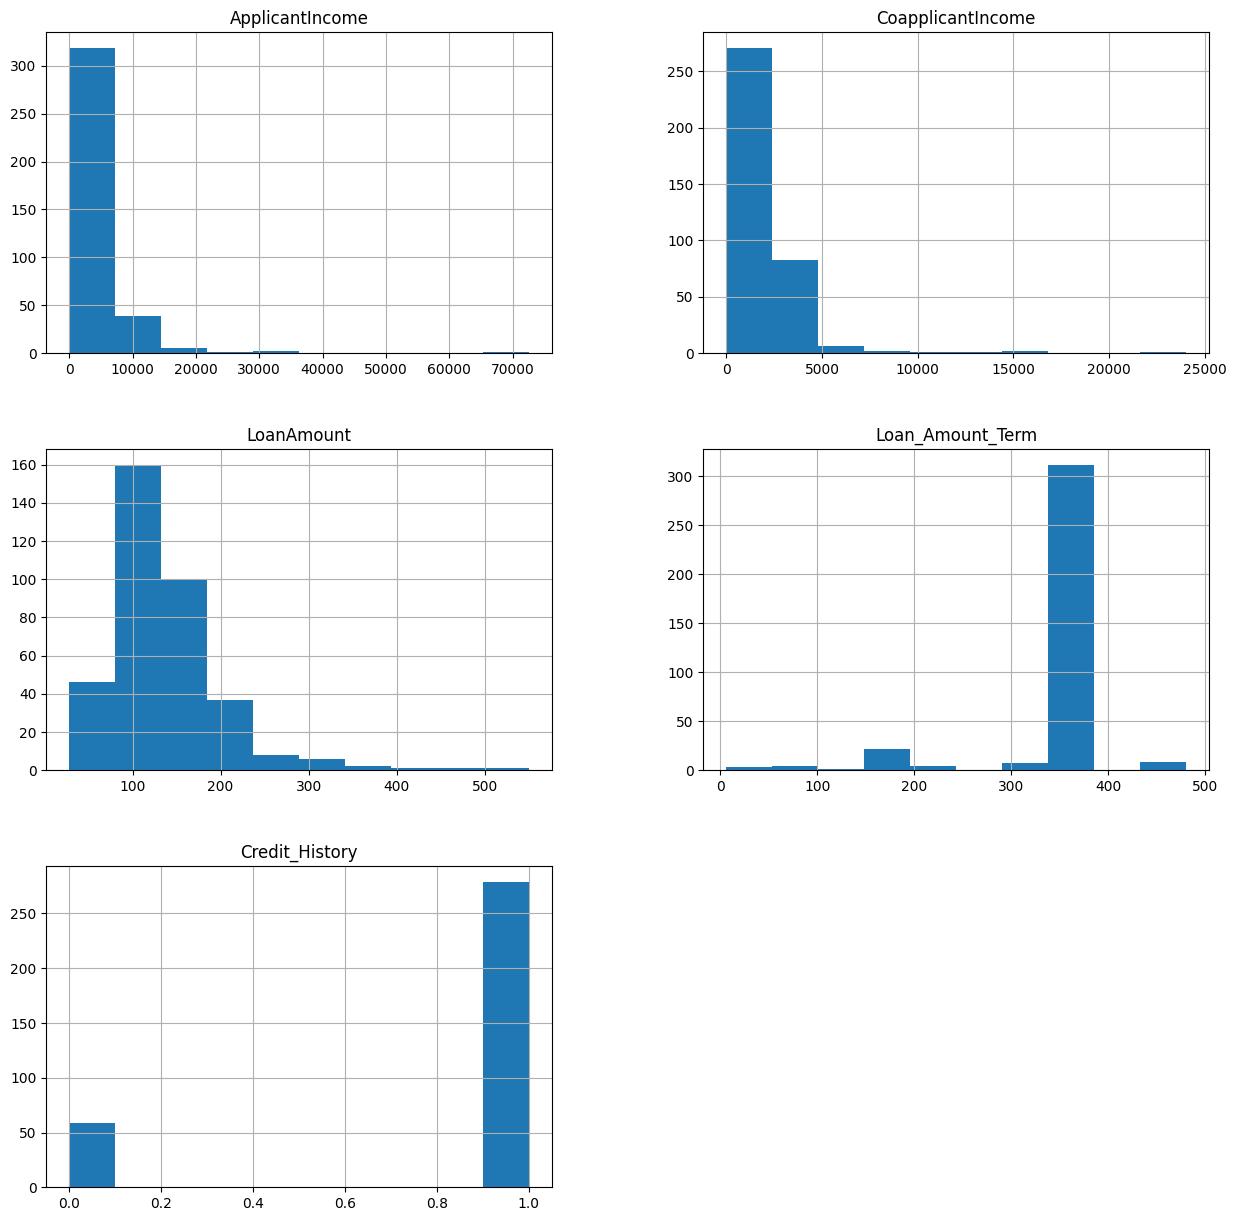

In [279]:
obj.hist(figsize=(15,15))

In [280]:
for i in obj.select_dtypes(include=['object']).columns:
  obj[i]=obj[i].fillna(obj[i].mode()[0])

In [281]:
obj.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [282]:
for i in obj[['LoanAmount','Loan_Amount_Term', 'Credit_History']]:
       obj[i]=obj[i].fillna(obj[i].median())

In [283]:
obj.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [284]:
obj['Gender']=obj['Gender'].map({'Male':1,'Female':0})
obj['Married']=obj['Married'].map({'Yes':1,'No':0})
obj['Education']=obj['Education'].map({'Graduate':1,'Not Graduate':0})
obj['Self_Employed']=obj['Self_Employed'].map({'Yes':1,'No':0})

In [285]:
obj=pd.get_dummies(obj,columns=['Dependents'])
obj=pd.get_dummies(obj,columns=['Property_Area'])
obj.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,1,1,0,5720,0,110.0,360.0,1.0,True,False,False,False,False,False,True
1,1,1,1,0,3076,1500,126.0,360.0,1.0,False,True,False,False,False,False,True
2,1,1,1,0,5000,1800,208.0,360.0,1.0,False,False,True,False,False,False,True
3,1,1,1,0,2340,2546,100.0,360.0,1.0,False,False,True,False,False,False,True
4,1,0,0,0,3276,0,78.0,360.0,1.0,True,False,False,False,False,False,True


In [286]:
#scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
obj['ApplicantIncome']=sc.fit_transform(obj[['ApplicantIncome']])
obj['CoapplicantIncome']=sc.fit_transform(obj[['CoapplicantIncome']])
obj['LoanAmount']=sc.fit_transform(obj[['LoanAmount']])
obj['Loan_Amount_Term']=sc.fit_transform(obj[['Loan_Amount_Term']])

In [287]:
New_pred=svm.predict(obj)

In [288]:
New_pred

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,

In [289]:
New_pred=pd.DataFrame(New_pred,columns=['Loan_Status'])

In [290]:
New_pred=New_pred.replace({1:'Y',0:'N'})

In [291]:
New_pred

,Loan_Status
0,Y
1,Y
2,Y
3,Y
4,Y
...,...
362,Y
363,Y
364,Y
365,Y


In [292]:
id=pd.DataFrame(test['Loan_ID'])

In [293]:
Output=pd.concat([id,New_pred],axis=1)

In [294]:
Output

,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y
...,...,...
362,LP002971,Y
363,LP002975,Y
364,LP002980,Y
365,LP002986,Y


In [295]:
Output.to_csv('Output.csv')